In [1]:
#### HOUSE PRICE PREDICTION  ####

# STEP 1

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
import seaborn as sns



from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [3]:
df = pd.read_csv('house-price-data.csv')

In [4]:
df['SaleCondition'].value_counts()

Normal     1198
Partial     125
Abnorml     101
Family       20
Alloca       12
AdjLand       4
Name: SaleCondition, dtype: int64

In [5]:
from sklearn.preprocessing import LabelEncoder

In [6]:
label = LabelEncoder()

x =label.fit_transform(df['SaleCondition']) 

xy = pd.get_dummies(df['SaleCondition'])

In [7]:
xy

,Abnorml,AdjLand,Alloca,Family,Normal,Partial
0,0,0,0,0,1,0
1,0,0,0,0,1,0
2,0,0,0,0,1,0
3,1,0,0,0,0,0
4,0,0,0,0,1,0
...,...,...,...,...,...,...
1455,0,0,0,0,1,0
1456,0,0,0,0,1,0
1457,0,0,0,0,1,0
1458,0,0,0,0,1,0


In [8]:
df['SaleCondition'].value_counts()

Normal     1198
Partial     125
Abnorml     101
Family       20
Alloca       12
AdjLand       4
Name: SaleCondition, dtype: int64

In [9]:
df['SaleCondition']

0        Normal
1        Normal
2        Normal
3       Abnorml
4        Normal
         ...   
1455     Normal
1456     Normal
1457     Normal
1458     Normal
1459     Normal
Name: SaleCondition, Length: 1460, dtype: object

In [10]:
df.head(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500


In [11]:
df.tail(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [12]:
df.shape

(1460, 81)

In [13]:
df['MSZoning'].value_counts()

RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: MSZoning, dtype: int64

In [14]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [15]:
#df.info

In [16]:
#df.describe

<AxesSubplot:>

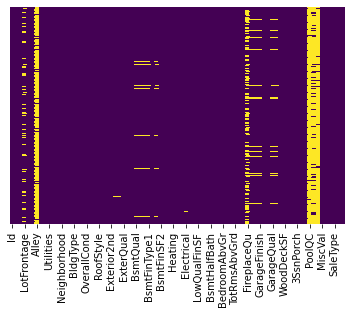

In [17]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis') #Check null values through heatmap

In [18]:
#df['LotFrontage']

In [19]:
df['LotFrontage'].mean()

70.04995836802665

## STEP 2

In [20]:
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].mean()) #Fill NA values with appropriate value

In [21]:
df.drop(['Alley'],axis=1,inplace=True) #Drop columns that are not needed

In [22]:
df.head(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500


In [23]:
df.shape

(1460, 80)

In [24]:
1,1,1,1,1,1,2,2,2,3,3

(1, 1, 1, 1, 1, 1, 2, 2, 2, 3, 3)

In [25]:
df['BsmtCond'].value_counts()

TA    1311
Gd      65
Fa      45
Po       2
Name: BsmtCond, dtype: int64

In [26]:
df['BsmtCond'].mode()[0]

'TA'

In [27]:
df['BsmtCond'] = df['BsmtCond'].fillna(df['BsmtCond'].mode()[0])
df['BsmtQual'] = df['BsmtQual'].fillna(df['BsmtQual'].mode()[0])
df['FireplaceQu'] = df['FireplaceQu'].fillna(df['FireplaceQu'].mode()[0])
df['GarageType'] = df['GarageType'].fillna(df['GarageType'].mode()[0])

In [28]:
df.drop(['GarageYrBlt'],axis=1,inplace=True)

In [29]:
df['GarageFinish'] = df['GarageFinish'].fillna(df['GarageFinish'].mode()[0])
df['GarageQual'] = df['GarageQual'].fillna(df['GarageQual'].mode()[0])
df['GarageCond'] = df['GarageCond'].fillna(df['GarageCond'].mode()[0])
#df['GarageType'] = df['GarageType'].fillna(df['GarageType'].mode()[0])

In [30]:
df.drop(['PoolQC','Fence','MiscFeature'],axis=1,inplace=True)

In [31]:
df.drop(['Id'],axis=1,inplace=True)

In [32]:
df.shape

(1460, 75)

In [33]:
#df.columns

In [34]:
df.isnull().sum()

MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 75, dtype: int64

In [35]:
df['MasVnrType'] = df['MasVnrType'].fillna(df['MasVnrType'].mode()[0])
df['MasVnrArea'] = df['MasVnrArea'].fillna(df['MasVnrArea'].mode()[0])

<AxesSubplot:>

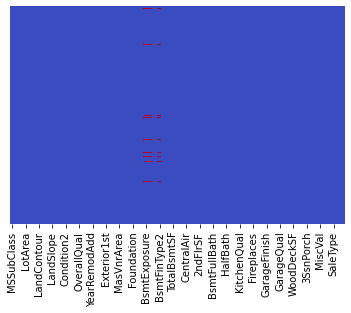

In [36]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='coolwarm')

In [37]:
#sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [38]:
df['BsmtExposure'] = df['BsmtExposure'].fillna(df['BsmtExposure'].mode()[0])

In [39]:
df['BsmtFinType1'] = df['BsmtFinType1'].fillna(df['BsmtFinType1'].mode()[0])

<AxesSubplot:>

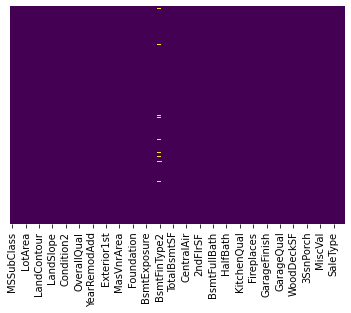

In [40]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [41]:
df.dropna(inplace=True)

<AxesSubplot:>

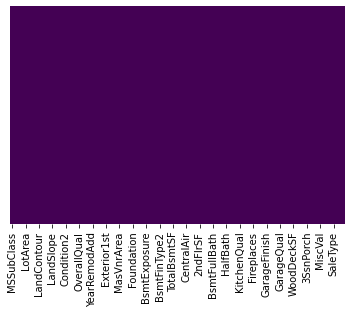

In [42]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [43]:
df.head(2)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500


In [44]:
df.shape

(1421, 75)

In [45]:
#df.isnull().sum()

<AxesSubplot:>

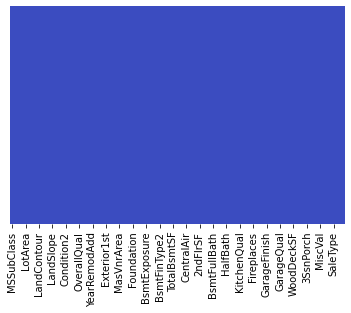

In [46]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='coolwarm')

In [47]:
col = df.columns

In [48]:
col

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageFinish',
       'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive',
       'WoodDeckSF', 'OpenPorchSF'

In [49]:
len(col)

75

In [50]:
numeric = list(df.dtypes[df.dtypes!='object'].index)

In [51]:
numeric

['MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'SalePrice']

In [52]:
len(numeric)

36

In [53]:
#df['YrSold']

In [54]:
df.head(2)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500


In [55]:
train = df[numeric]

In [56]:
train.head(2)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500


In [57]:
type(train)

pandas.core.frame.DataFrame

In [58]:
#train_scaled

In [59]:
train.shape

(1421, 36)

In [60]:
train.isnull().sum()

MSSubClass       0
LotFrontage      0
LotArea          0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
MasVnrArea       0
BsmtFinSF1       0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
TotRmsAbvGrd     0
Fireplaces       0
GarageCars       0
GarageArea       0
WoodDeckSF       0
OpenPorchSF      0
EnclosedPorch    0
3SsnPorch        0
ScreenPorch      0
PoolArea         0
MiscVal          0
MoSold           0
YrSold           0
SalePrice        0
dtype: int64

In [61]:
#xtest

In [62]:
#train.iloc[row_starting_index : row_ending_index , col_starting_index : col_ending_index]

In [63]:
price = train.iloc[:,35:36] #OUTPUT

#price = train['SalePrice']
price.head(2)

,SalePrice
0,208500
1,181500


In [64]:
train = train.iloc[:,:-1]  #INPUT
train.head(2)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,548,0,61,0,0,0,0,0,2,2008
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,460,298,0,0,0,0,0,0,5,2007


In [65]:
#100% ....80% training 20% test

In [66]:
#input = 100
#output = 100


#training_input = 80    #xtrain
#training_output = 80   #ytrain

#test_input = 20    #xtest
#testing_output = 20  #ytest



#random state

#100 .... 

#80 training data ...randomly selected data out of 100
#20 testing data


#80 ... model accuracy = 85
#20 ...  model accuracy = 75


In [67]:
#Splitting the dataset into training and testing data
xtrain,xtest,ytrain,ytest = train_test_split(train,
                                             price,
                                             test_size=0.2,
                                             random_state=40)

In [68]:
print(len(xtrain), len(ytrain),len(xtest),len(ytest))

1136 1136 285 285


In [69]:
xtrain.head(10)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
168,60,62.000000,8244,7,5,2004,2004,0.0,0,0,...,440,100,48,0,0,0,0,0,5,2007
228,20,70.000000,8521,5,5,1967,1967,0.0,842,0,...,336,0,0,0,0,0,0,0,5,2010
1097,120,70.049958,3696,8,5,1986,1986,0.0,0,0,...,461,0,74,137,0,0,0,0,10,2007
884,20,65.000000,7150,5,5,1967,1967,60.0,432,0,...,288,0,0,0,0,0,0,0,7,2009
1297,180,35.000000,3675,6,5,2005,2006,82.0,547,0,...,525,0,44,0,0,0,0,0,6,2006
447,60,70.049958,11214,7,5,1998,1999,0.0,0,0,...,431,89,0,0,0,0,0,0,7,2006
788,20,50.000000,6000,4,7,1954,2000,0.0,0,0,...,281,0,0,0,0,0,0,0,8,2008
978,20,68.000000,9450,4,5,1954,1954,0.0,552,0,...,400,0,0,0,0,0,0,0,5,2007
929,60,70.049958,13006,7,5,1997,1997,285.0,0,0,...,642,0,0,0,0,0,0,0,11,2006
284,120,50.000000,8012,6,5,1992,1992,0.0,430,0,...,529,0,0,52,0,0,0,0,7,2007


In [70]:
#ytrain

In [71]:
#xtest

In [72]:
#ytest

In [73]:
ytrain.head(2)

,SalePrice
168,183500
228,125000


## STEP 3

In [74]:
# PREPROCESSING ##################

In [75]:
from sklearn.preprocessing import StandardScaler

In [76]:
scaler = StandardScaler()

In [77]:
###INPUT DATA TRANSFORMATION

In [78]:
xtrain_scaled = scaler.fit_transform(xtrain)

In [79]:
xtrain_scaled

array([[ 1.01097709e-01, -3.72341154e-01, -2.30311686e-01, ...,
        -1.09597356e-01, -5.06922501e-01, -6.06445742e-01],
       [-8.54964708e-01, -1.08424403e-03, -2.05038876e-01, ...,
        -1.09597356e-01, -5.06922501e-01,  1.66223383e+00],
       [ 1.53519134e+00,  1.23417964e-03, -6.45260209e-01, ...,
        -1.09597356e-01,  1.34711472e+00, -6.06445742e-01],
       ...,
       [ 1.01097709e-01,  1.23417964e-03, -3.52457365e-02, ...,
         1.08054600e+00,  1.71792216e+00,  9.06007305e-01],
       [ 2.49125375e+00, -2.27503282e+00, -8.29195174e-01, ...,
        -1.09597356e-01, -5.06922501e-01,  9.06007305e-01],
       [-8.54964708e-01, -1.30048343e+00,  3.76235758e-01, ...,
        -1.09597356e-01,  1.34711472e+00,  9.06007305e-01]])

In [80]:
#xtrain_scaled

In [81]:
xtest_scaled = scaler.transform(xtest)

In [82]:
#ytest

In [83]:
### FIT TRANSFORM - Training Data
### TRANSFORM - Testing Data


In [84]:
regressor = LinearRegression()   #Initialize linear regressor

In [85]:
regressor.fit(xtrain_scaled,ytrain)   #Train the model

LinearRegression()

In [86]:
 regressor.score(xtrain_scaled,ytrain)   #Check accuracy on training data

0.8547451760905891

In [87]:
 regressor.score(xtest_scaled,ytest)    #Check accuracy on testing data

0.5190412461276942

In [88]:
reg = regressor.predict(xtest_scaled)    #Predict the house price

In [89]:
reg.shape

(285, 1)

In [90]:
ytest_li = []
for i in ytest.SalePrice:
    ytest_li.append(i)

In [91]:
for i in range(len(reg)):
    print(reg[i] , ytest_li[i])

[217561.56620916] 222000
[238284.03095065] 207500
[186449.32202786] 181000
[155391.81998189] 144500
[290398.76767639] 293077
[163092.64829566] 155000
[252692.61249775] 260400
[112824.15388529] 119000
[199241.17512403] 173000
[103700.52251329] 108000
[202841.098225] 201000
[284599.49036773] 240000
[284990.85666211] 270000
[47127.48252417] 151500
[149145.04289339] 143000
[155954.04602563] 169900
[173023.22371134] 163000
[227647.07762851] 245500
[144098.42118983] 160000
[277325.84281642] 250000
[145255.83756344] 157500
[108516.78438971] 114500
[289191.36351704] 268000
[300828.23156183] 314813
[51478.60669583] 80000
[318622.55977382] 340000
[322264.95080436] 337000
[222205.22026898] 250000
[198149.16812928] 194000
[101688.19740278] 110000
[215693.9766429] 214000
[190193.93053788] 176000
[61648.62210881] 83000
[128312.89449722] 117000
[210834.81961367] 176000
[110319.77657199] 120000
[159210.95156349] 144000
[145932.36478534] 134000
[84795.25885475] 79000
[185738.86806294] 172500
[212930.69

In [92]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [93]:
ytest_scaled = scaler.fit_transform(ytest)

In [94]:
reg_scaled = scaler.transform(reg)     #Need to transform the predicted price to check mse and mae

In [95]:
reg_scaled

array([[ 4.15134035e-01],
       [ 6.77808452e-01],
       [ 2.07605516e-02],
       [-3.72919030e-01],
       [ 1.33840594e+00],
       [-2.75304648e-01],
       [ 8.60449166e-01],
       [-9.12499481e-01],
       [ 1.82907893e-01],
       [-1.02814907e+00],
       [ 2.28539902e-01],
       [ 1.26489529e+00],
       [ 1.26985618e+00],
       [-1.74525925e+00],
       [-4.52102107e-01],
       [-3.65792349e-01],
       [-1.49426373e-01],
       [ 5.42976252e-01],
       [-5.16072220e-01],
       [ 1.17269578e+00],
       [-5.01401009e-01],
       [-9.67098960e-01],
       [ 1.32310109e+00],
       [ 1.47060804e+00],
       [-1.69010514e+00],
       [ 1.69616590e+00],
       [ 1.74233622e+00],
       [ 4.73996199e-01],
       [ 1.69065799e-01],
       [-1.05365696e+00],
       [ 3.91460789e-01],
       [ 6.82265683e-02],
       [-1.56119177e+00],
       [-7.16166856e-01],
       [ 3.29866946e-01],
       [-9.44244540e-01],
       [-3.24508371e-01],
       [-4.92825465e-01],
       [-1.2

In [96]:
#mean_squared_error(ytest,reg) #mean_squared_error

In [97]:
mean_squared_error(ytest_scaled,reg_scaled) #mean_squared_error

0.4809587538723058

In [98]:
mean_squared_error(ytest_scaled,reg_scaled, squared=False) #root_mean_squared_error

0.6935118988685817

In [99]:
mean_absolute_error(ytest_scaled,reg_scaled) #mean_absolute_error

0.2992732035483763

In [100]:
#Linear regressor does not perform well

In [101]:
######Test Set

In [102]:
test = pd.read_csv('house-price-data.csv')    #test the model on any other data

In [103]:
test.head(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500


In [104]:
test.shape

(1460, 81)

In [105]:
test = pd.read_csv('house-price-data.csv')

#test.info()

#test.isnull().sum()
test['MSZoning'].value_counts()


test['LotFrontage'] = test['LotFrontage'].fillna(test['LotFrontage'].mean())

test.drop(['Alley'],axis=1,inplace=True)

test['MSZoning'] = test['MSZoning'].fillna(test['MSZoning'].mode()[0])

test['BsmtCond'] = test['BsmtCond'].fillna(test['BsmtCond'].mode()[0])
test['BsmtQual'] = test['BsmtQual'].fillna(test['BsmtQual'].mode()[0])
test['FireplaceQu'] = test['FireplaceQu'].fillna(test['FireplaceQu'].mode()[0])
test['GarageType'] = test['GarageType'].fillna(test['GarageType'].mode()[0])

test.drop(['GarageYrBlt'],axis=1,inplace=True)

test['GarageFinish'] = test['GarageFinish'].fillna(test['GarageFinish'].mode()[0])
test['GarageQual'] = test['GarageQual'].fillna(test['GarageQual'].mode()[0])
test['GarageCond'] = test['GarageCond'].fillna(test['GarageCond'].mode()[0])
test['GarageType'] = test['GarageType'].fillna(test['GarageType'].mode()[0])

test.drop(['PoolQC','Fence','MiscFeature'],axis=1,inplace=True)

test.drop(['Id'],axis=1,inplace=True)

#test.shape

#test.columns

test['MasVnrType'] = test['MasVnrType'].fillna(test['MasVnrType'].mode()[0])
test['MasVnrArea'] = test['MasVnrArea'].fillna(test['MasVnrArea'].mode()[0])

test['BsmtExposure'] = test['BsmtExposure'].fillna(test['BsmtExposure'].mode()[0])
test['BsmtFinType2'] = test['BsmtFinType2'].fillna(test['BsmtFinType2'].mode()[0])


test.dropna(inplace=True)

#test.shape

#test.shape

#test.isnull().sum()

test['MasVnrType'] = test['MasVnrType'].fillna(test['MasVnrType'].mode()[0])
test['MasVnrArea'] = test['MasVnrArea'].fillna(test['MasVnrArea'].mode()[0])

test['BsmtExposure'] = test['BsmtExposure'].fillna(test['BsmtExposure'].mode()[0])


#test.drop(['Id'],axis=1,inplace=True)

test['BsmtExposure'] = test['BsmtExposure'].fillna(test['BsmtExposure'].mode()[0])


numeric = list(test.dtypes[test.dtypes!='object'].index)

test = test[numeric]

#test.shape


RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: MSZoning, dtype: int64

In [106]:
test.head(2)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500


In [107]:
################### Training the model using random forest 

In [108]:
from sklearn.ensemble import RandomForestRegressor

In [109]:
regr =RandomForestRegressor()

In [110]:
regr.fit(xtrain_scaled,ytrain)

<ipython-input-110-ebeacc4026c2>:1: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  regr.fit(xtrain_scaled,ytrain)


RandomForestRegressor()

In [111]:
regr.score(xtrain_scaled,ytrain)

0.9803034069570489

In [112]:
regr.score(xtest_scaled,ytest)

0.8289656163838585

In [113]:
predicted_value = regr.predict(xtest_scaled)

In [114]:
predicted_value.shape

(285,)

In [115]:
#predicted_value

In [116]:
ytest_li = []
for i in ytest.SalePrice:
    ytest_li.append(i)

In [117]:
for i in range(len(predicted_value)):
    #print(predicted_value[i] , ytest_li[i])
    pass

In [118]:
ytest_scaled2 = scaler.fit_transform(ytest)   #Need to transform to check MSE and MAE

In [119]:
#ytest_scaled2

In [120]:
reg_scaled2 = scaler.transform(predicted_value.reshape(-1,1))

In [121]:
#reg_scaled2

In [122]:
#reg_scaled2 = scaler.transform(reg_scaled2)

In [123]:
mean_squared_error(ytest_scaled2,reg_scaled2)

0.17103438361614157

In [124]:
mean_squared_error(ytest_scaled2,reg_scaled2, squared = False) #RMSE

0.4135630346345543

In [125]:
mean_absolute_error(ytest_scaled2,reg_scaled2)

0.2400358948860641

In [126]:
predicted_value

array([199022.3       , 235072.26      , 179104.2       , 152527.39      ,
       300618.82      , 165796.        , 231246.84      , 122825.71      ,
       160755.8       , 120869.38      , 197182.9       , 268526.8       ,
       302050.07      , 128877.5       , 136316.5       , 143458.5       ,
       153186.82      , 222434.44      , 141381.76      , 276303.27      ,
       147119.05      , 123120.5       , 344985.31      , 289463.6       ,
        81883.44      , 313534.31      , 327599.64      , 215168.11      ,
       193886.91      , 118611.38      , 198671.34      , 162981.5       ,
        93700.81      , 121054.54      , 209607.        , 119620.96      ,
       150766.24      , 150456.24      , 112505.92      , 171146.7       ,
       206110.31      , 134105.48      , 111512.17      , 217406.74      ,
       110809.5       , 365913.49      , 180794.07      , 196606.34      ,
       125530.        , 115850.47      , 314420.66      , 127633.6       ,
       156515.97      , 1

In [127]:
#######################################################

In [128]:
#######################################################

In [129]:
#predicted_value.to_list()

In [130]:
#pre = predicted_value.tolist()

In [131]:
pre = predicted_value.tolist()

In [132]:
predicted_value.shape

(285,)

In [133]:
li =[]
li.append(pre)

In [134]:
predicted_value

array([199022.3       , 235072.26      , 179104.2       , 152527.39      ,
       300618.82      , 165796.        , 231246.84      , 122825.71      ,
       160755.8       , 120869.38      , 197182.9       , 268526.8       ,
       302050.07      , 128877.5       , 136316.5       , 143458.5       ,
       153186.82      , 222434.44      , 141381.76      , 276303.27      ,
       147119.05      , 123120.5       , 344985.31      , 289463.6       ,
        81883.44      , 313534.31      , 327599.64      , 215168.11      ,
       193886.91      , 118611.38      , 198671.34      , 162981.5       ,
        93700.81      , 121054.54      , 209607.        , 119620.96      ,
       150766.24      , 150456.24      , 112505.92      , 171146.7       ,
       206110.31      , 134105.48      , 111512.17      , 217406.74      ,
       110809.5       , 365913.49      , 180794.07      , 196606.34      ,
       125530.        , 115850.47      , 314420.66      , 127633.6       ,
       156515.97      , 1

In [135]:
result = pd.DataFrame({"Actual price":ytest_li,"Predicted price":predicted_value})

In [136]:
#result

In [137]:
result.to_csv("house-price.csv",index=False) #to save result in csv file